<a href="https://colab.research.google.com/github/JohnDoedid/SFX-1/blob/main/LuminanceSpectrum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

rainbow_colored_a = [
      (0, 0, 255),       # Blue
      (75, 0, 130),      # Indigo
      (255, 0, 0),       # Red
      (148, 0, 211),     # Violet
      (255, 127, 0),     # Orange
      (255, 0, 255),     # Magenta
      (0, 255, 0),       # Green
      (255, 255, 0),     # Cyan
      (0, 255, 255),     # Yellow
      (255, 255, 255)    # White
]

# Create a sorted array by luminance for the loops
def luminance(rgb):
    R, G, B = rgb
    return 0.2126*R + 0.7152*G + 0.0722*B

rainbow_colors = sorted(rainbow_colored_a, key=luminance)



# Image settings
width = 2335
height_top = 250     # Grayscale part
height_bottom = 250   # Color reference at bottom
height_total = height_top + height_bottom

# Create empty array for the full image
img_array = np.zeros((height_total, width, 3), dtype=np.uint8)

# Calculate pixels per segment
segment_width = width / (len(rainbow_colors) - 1)

# ---------- TOP: Grayscale luminance spectrum ----------
for i in range(len(rainbow_colors) - 1):
    start_color = np.array(rainbow_colors[i])
    end_color = np.array(rainbow_colors[i + 1])
    for x in range(int(segment_width * i), int(segment_width * (i + 1))):
        t = (x - segment_width * i) / segment_width  # interpolation factor
        # Blend the colors for smooth transition
        color = (1 - t) * start_color + t * end_color
        img_array[:height_top, x, :] = color.astype(np.uint8)

# Convert top part to grayscale
img_top = Image.fromarray(img_array[:height_top])
luminance_top = img_top.convert("L")
img_array[:height_top] = np.stack([np.array(luminance_top)]*3, axis=2)  # apply grayscale

# ---------- BOTTOM: Colored spectrum ----------
for i in range(len(rainbow_colors) - 1):
    start_color = np.array(rainbow_colors[i])
    end_color = np.array(rainbow_colors[i + 1])
    for x in range(int(segment_width * i), int(segment_width * (i + 1))):
        t = (x - segment_width * i) / segment_width
        color = (1 - t) * start_color + t * end_color
        img_array[height_top:, x, :] = color.astype(np.uint8)  # only bottom rows
img = Image.fromarray(img_array)
img.save("/content/luminance.png")
print("Saved full spectrum image as /content/luminance.png")
# Display in Colab
img.show()


Saved full spectrum image as /content/luminance.png


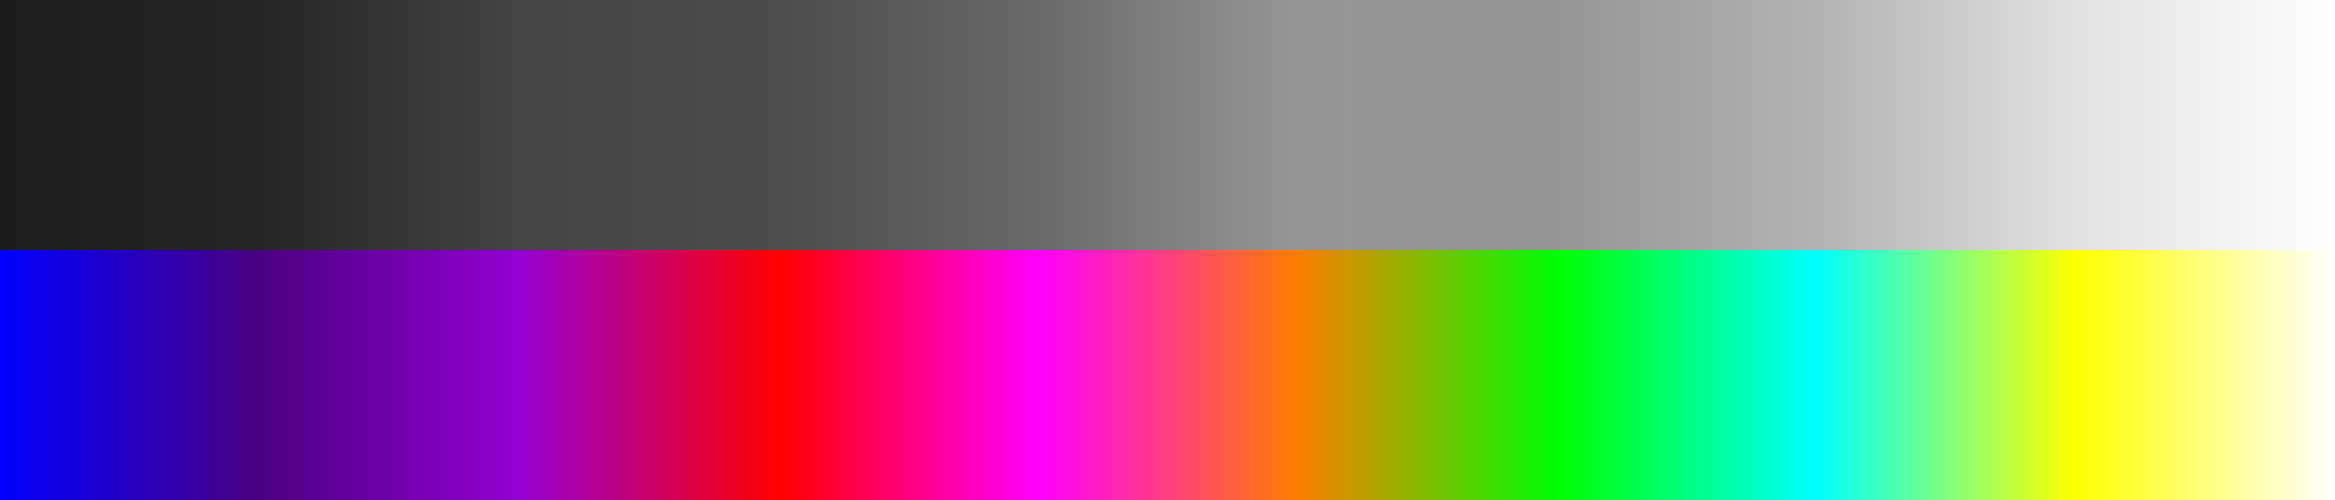

In [ ]:
from IPython.display import display
from PIL import Image

# Open the image (you already saved it)
luminance_img = Image.open("/content/luminance.png")

# Display it in Colab
display(luminance_img)

